## **LOAD LIBRARIES & DATASET**

### Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

### Dataset

In [2]:
salarydf_copy = pd.read_csv("preprocessed_data_unencoded.csv")
salarydf_copy2 = pd.read_csv("preprocessed_data_encoded.csv")
salarydf_copy2.head(5)

,location,career_level,experience_level,education_level,employment_type,job_function,company_process_time,company_industry,Salary Level
0,13,4,1,15,4,21,18,30,2
1,1,4,3,15,4,1,22,21,2
2,4,3,1,8,4,0,29,30,1
3,9,3,2,15,4,22,29,7,2
4,4,2,2,18,4,37,29,23,2


__Meta Data__ :

| Column               | Description                                                                |
| -------------------- | -------------------------------------------------------------------------- |
| `id`                 | Unique identifier for each data record.                                    |
| `job_title`          | Name or title of the job.                                                  |
| `location`           | Location of the company or job.                                            |
| `salary_currency`    | Currency used for the salary.                                              |
| `career_level`       | Career level of the position, such as staff, manager, director, or CEO.    |
| `experience_level`   | Level of work experience required from applicants.                         |
| `education_level`    | Minimum education level required from applicants.                          |
| `employment_type`    | Type of employment, such as full-time, part-time, contract, or internship. |
| `job_function`       | Functional category of the job.                                            |
| `job_benefits`       | Benefits provided by the company.                                          |
| `companyprocesstime` | Average time taken by the company to respond to applicants.                |
| `company_size`       | Number of employees in the company.                                        |
| `company_industry`   | Industry or business sector of the company.                                |
| `job_description`    | Description of the job responsibilities and requirements.                  |
| `salary`             | Monthly salary offered by the company, based on data from March 2022.      |

__Explanation__:

| Section               | Description                                                                                                                                                                                                                                                                                                                                                                                                                      |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Problem Statement** | Many people want to find jobs based on the offered salary range. In this dataset, each record is classified into one of three salary classes based on the Provincial Minimum Wage or **UMP** of the job location: **Rendah** — salary less than or equal to the province's UMP; **Sedang** — salary greater than the UMP and less than or equal to twice the UMP; and **Tinggi** — salary greater than twice the province's UMP. |
| **Goal**              | Predict the salary class of a job based on its field of work, particularly the `career_level`, `job_function`, and `location` variables.                                                                                                                                                                                                                                                                                         |
| **Target Output**     | Predicted salary-level class: **Rendah**, **Sedang**, or **Tinggi**.                                                                                                                                                                                                                                                                                                                                                             |

## **DATA PRE-PROCESSING**

### Data split
Split data into 60% training, 20% validation, and 20% testing

In [3]:
x = salarydf_copy2.drop(['Salary Level'], axis = 1)
y = salarydf_copy2['Salary Level']

#split data into train, test, and validation set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, shuffle = True, random_state = 42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, shuffle = True, random_state = 42)

# check the shape of train, test, and validation sets
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

x_train: (5605, 8)
y_train: (5605,)
x_test: (1869, 8)
y_test: (1869,)
x_val: (1869, 8)
y_val: (1869,)


### Standard Scaler

In [4]:
# Fit scaler on training data
st = StandardScaler()
x_train = st.fit_transform(x_train)

Apply on validation and testing data
x_val = st.transform(x_val)
x_test = st.transform(x_test)

__Explanation__:

- We standardized the predictors so they can have similar range, which is necessary for distance-based and gradient-based models.
- Standard Scaler is used for scaling method so it would not be easily affected by outliers.

### Balancing Classes

In [5]:
# See proportion of salary level
y_train.value_counts()

Salary Level
1    2498
2    2465
0     642
Name: count, dtype: int64

__Explanation__:

The classes in our target variable are imbalanced, because the class 'Sedang' and 'Tinggi' have ~2500 records, but class 'Rendah' only has around 600 records. Therefore, we will balance the classes using SMOTE technique, so the classifiers can generate a better model.

In [6]:
y_train = y_train.astype(int)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

y_train.value_counts()

Salary Level
2    2498
1    2498
0    2498
Name: count, dtype: int64

Now all 3 classes become balanced with the same number of record.

## **MODELING BEFORE TUNING**

### Individual Classifier

**1. Logistic Regression Model**

In [7]:
ls = LogisticRegression(multi_class = 'multinomial')
lrModel = ls.fit(x_train, y_train)
lrPred = ls.predict(x_val)
print(classification_report(y_val, lrPred))

              precision    recall  f1-score   support

           0       0.21      0.60      0.32       209
           1       0.50      0.37      0.43       851
           2       0.64      0.52      0.58       809

    accuracy                           0.46      1869
   macro avg       0.45      0.50      0.44      1869
weighted avg       0.53      0.46      0.48      1869



__Explanation__:

The logistic regression model comes out with the f1-score of 44%, we use multinomial classifier as it gives higher performance than OVR and OVO classifier.

**2. KNN**

In [8]:
knn = KNeighborsClassifier()
knnModel = knn.fit(x_train, y_train)
knnPred = knn.predict(x_val)
print(classification_report(y_val, knnPred))

              precision    recall  f1-score   support

           0       0.29      0.66      0.40       209
           1       0.63      0.51      0.57       851
           2       0.71      0.61      0.66       809

    accuracy                           0.57      1869
   macro avg       0.54      0.59      0.54      1869
weighted avg       0.63      0.57      0.59      1869



__Explanation__:

By using the K-Nearest Neighbor (KNN) method, the model f1-score is 54%. This means that is an increase in performance compared to the Logistic Regression method.

**3. Decision Tree**

In [9]:
dt = DecisionTreeClassifier(random_state = 42)
dtModel = dt.fit(x_train, y_train)
dtPred = dt.predict(x_val)
print(classification_report(y_val, dtPred))

              precision    recall  f1-score   support

           0       0.46      0.58      0.51       209
           1       0.69      0.68      0.68       851
           2       0.79      0.75      0.77       809

    accuracy                           0.70      1869
   macro avg       0.65      0.67      0.65      1869
weighted avg       0.71      0.70      0.70      1869



__Explanation__:

The f1-score we got from the decision tree model is 65%. The model gives better performance than the last 2 models.

**4. Support Vector Machine**

In [10]:
svm = SVC(random_state = 42)
svmModel = svm.fit(x_train, y_train)
svmPred = svm.predict(x_val)
print(classification_report(y_val, svmPred))

              precision    recall  f1-score   support

           0       0.20      0.55      0.29       209
           1       0.51      0.41      0.46       851
           2       0.69      0.52      0.59       809

    accuracy                           0.47      1869
   macro avg       0.47      0.49      0.45      1869
weighted avg       0.56      0.47      0.50      1869



__Explanation__:

The Support Vector Machine (SVM) method produces a model f1-score of 45%, similar to the Logistic Regression. However, the performance of this model is lower than the Decision Tree model.

__Individual Classifier Method__
> Out of all 4 classifiers, the model with the highest accuracy is Decision Tree.

### Ensemble Method

**1. Voting Classifier**

In [11]:
#create a dictionary of our models
estimators = [('svm', svm), ('KNN', knn), ('DecisionTree', dt)]

#create our voting classifier, inputting our models
ensemble_vc = VotingClassifier(estimators, voting='hard')

#fit model to training data
ensembleModel = ensemble_vc.fit(x_train, y_train)
ensemblePred = ensemble_vc.predict(x_val)
print(classification_report(y_val, ensemblePred))

              precision    recall  f1-score   support

           0       0.28      0.66      0.39       209
           1       0.68      0.57      0.62       851
           2       0.81      0.66      0.73       809

    accuracy                           0.62      1869
   macro avg       0.59      0.63      0.58      1869
weighted avg       0.69      0.62      0.64      1869



__Explanation__:

We try the combination of SVM, KNN, and Decision Tree classifiers. This model's f1-score is 58%.

**2. Bagging Classifier**

In [12]:
bagg = BaggingClassifier(estimator = dt, n_estimators = 100, random_state = 42)
baggModel = bagg.fit(x_train, y_train)
baggPred = bagg.predict(x_val)
print(classification_report(y_val, baggPred))

              precision    recall  f1-score   support

           0       0.54      0.60      0.57       209
           1       0.74      0.74      0.74       851
           2       0.83      0.81      0.82       809

    accuracy                           0.75      1869
   macro avg       0.70      0.72      0.71      1869
weighted avg       0.76      0.75      0.75      1869



__Explanation__:

In the Bagging Classifier method, we use our Decision Tree model as a base estimator. Using this model, we get a fairly high f1-score of 71%.

**3. Random Forest**

- **max_dept** : The maximum splits for all trees in the forest.
- **bootstrap** : An indicator of whether or not we want to use bootstrap samples when building trees.
- **max_features**: The maximum number of features taht will be used in node splitting.
- **criterion** : this is the metric used to asses the stopping criteria for the decision trees.

In [13]:
fit_rf = RandomForestClassifier(random_state = 42)
rfModel = fit_rf.fit(x_train, y_train)
rfPred = fit_rf.predict(x_val)
print(classification_report(y_val, rfPred))

              precision    recall  f1-score   support

           0       0.56      0.59      0.58       209
           1       0.74      0.73      0.74       851
           2       0.82      0.82      0.82       809

    accuracy                           0.75      1869
   macro avg       0.71      0.71      0.71      1869
weighted avg       0.76      0.75      0.76      1869



__Explanation__:

The random forest model has the f1-score of 71%., similar to bagging classifier.

**4. Boosting Classifier**

In [14]:
adaBoost = AdaBoostClassifier(estimator = dt, random_state = 42)
abModel = adaBoost.fit(x_train, y_train)
abPred = adaBoost.predict(x_val)
print(classification_report(y_val, abPred))

              precision    recall  f1-score   support

           0       0.51      0.60      0.55       209
           1       0.72      0.71      0.71       851
           2       0.81      0.78      0.80       809

    accuracy                           0.73      1869
   macro avg       0.68      0.70      0.69      1869
weighted avg       0.74      0.73      0.73      1869



__Explanation__:

The f1-score is 69%, slightly lower than the previous 2 methods.

__Ensemble Method__
> Out of all 4 classifiers, models with the highest accuracy are Bagging Classifier and Random Forest.

## **MODELING AFTER TUNING**

### Individual Classifier

**1. Logistic Regression Model**

In [15]:
ls = LogisticRegression(multi_class = 'multinomial')
param_grid = {'penalty' : ['l1', 'l2', 'elasticnet', None],
              'C' : [0.01, 0.1, 1, 10, 100],
              'solver' : ['newton-cg','sag','liblinear','lbfgs', 'saga']}
lr_grid = GridSearchCV(ls, param_grid = param_grid, cv = 10, n_jobs=3)
lrModel = lr_grid.fit(x_train, y_train)
lrPred = lr_grid.predict(x_val)
print(classification_report(y_val, lrPred))

              precision    recall  f1-score   support

           0       0.21      0.59      0.31       209
           1       0.51      0.38      0.43       851
           2       0.64      0.52      0.57       809

    accuracy                           0.46      1869
   macro avg       0.45      0.50      0.44      1869
weighted avg       0.53      0.46      0.48      1869



**2. KNN**

In [16]:
k_range = list(range(1, 20))
weight_options = ['uniform', 'distance']
param_grid = dict(n_neighbors=k_range, weights=weight_options)
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', return_train_score=False)

knnModel = knn_grid.fit(x_train, y_train)
knnPred = knn_grid.predict(x_val)
print(classification_report(y_val, knnPred))

              precision    recall  f1-score   support

           0       0.39      0.56      0.46       209
           1       0.65      0.65      0.65       851
           2       0.74      0.66      0.70       809

    accuracy                           0.64      1869
   macro avg       0.59      0.62      0.60      1869
weighted avg       0.66      0.64      0.65      1869



**3. Decision Tree**

In [17]:
dt = DecisionTreeClassifier(random_state = 42)
params = {'max_depth': [10,100,1000],
          'max_features': ['auto','sqrt','log2',None],
          'criterion': ['gini','entropy'],
          'max_leaf_nodes': [10,100,1000], 
          'min_samples_split': [2, 3, 4]}
grid_dt = GridSearchCV(dt, params, verbose = 1, cv = 10, n_jobs = 3)
dtModel = grid_dt.fit(x_train, y_train)
dtPred = grid_dt.predict(x_val)
print(classification_report(y_val, dtPred))

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
              precision    recall  f1-score   support

           0       0.47      0.59      0.52       209
           1       0.71      0.69      0.70       851
           2       0.80      0.78      0.79       809

    accuracy                           0.72      1869
   macro avg       0.66      0.68      0.67      1869
weighted avg       0.72      0.72      0.72      1869



**4. Support Vector Machine**

In [18]:
svm = SVC(random_state = 42)

param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']} 
svm_grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 0)

svmModel = svm_grid.fit(x_train, y_train)
svmPred = svm_grid.predict(x_val)
print(classification_report(y_val, svmPred))

              precision    recall  f1-score   support

           0       0.53      0.45      0.49       209
           1       0.67      0.66      0.66       851
           2       0.70      0.74      0.72       809

    accuracy                           0.67      1869
   macro avg       0.63      0.62      0.62      1869
weighted avg       0.67      0.67      0.67      1869



__Explanation__:

After tuning, the performance of all models increased. Out of all 4 classifiers, the highest accuracy remains from Decision Tree, with **67%** of f1-score (macro avg).

In our case, macro average is used for comparison because we have imbalanced validation set and want to treat all classes equally important. It is important to measure our model's performance not only for high-paying jobs, but also for medium and low-paying jobs.

### Ensemble Method

**1. Voting Classifier**

In [19]:
# Create a dictionary of our models
estimators = [('svm', svm), ('KNN', knn), ('DecisionTree', dt)]

# Create our voting classifier, inputting our models
ensemble_vc = VotingClassifier(estimators, voting='hard')

# Fit model to training data
params = {'voting': ['hard', 'soft'], 
          'weights': [(1,1,1), (2,1,1), (1,2,1), (1,1,2)]}
grid_vote = GridSearchCV(ensemble_vc, params)

ensembleModel = grid_vote.fit(x_train, y_train)
ensemblePred = grid_vote.predict(x_val)
print(classification_report(y_val, ensemblePred))

              precision    recall  f1-score   support

           0       0.35      0.65      0.45       209
           1       0.65      0.64      0.64       851
           2       0.82      0.66      0.73       809

    accuracy                           0.65      1869
   macro avg       0.61      0.65      0.61      1869
weighted avg       0.69      0.65      0.66      1869



**2. Bagging Classifier**

In [20]:
bagg = BaggingClassifier(estimator = dt, n_estimators = 100, random_state = 42)
param_dist = {'bootstrap': [True, False],
              'estimator__max_depth': [10,100,1000],
              'estimator__max_features': ['auto','sqrt','log2',None],
              'estimator__criterion': ['gini','entropy'],
              'estimator__max_leaf_nodes': [10,100,1000], 
              'estimator__min_samples_split': [2, 3, 4]}

grid_bagg = GridSearchCV(bagg, cv = 10, param_grid = param_dist, n_jobs=3)
baggModel = grid_bagg.fit(x_train, y_train)

# calculate the score
baggPred = grid_bagg.predict(x_val)
print(classification_report(y_val, baggPred))

              precision    recall  f1-score   support

           0       0.56      0.63      0.59       209
           1       0.75      0.73      0.74       851
           2       0.83      0.83      0.83       809

    accuracy                           0.76      1869
   macro avg       0.71      0.73      0.72      1869
weighted avg       0.77      0.76      0.76      1869



**3. Random Forest**

- **max_dept** : The maximum splits for all trees in the forest.
- **bootstrap** : An indicator of whether or not we want to use bootstrap samples when building trees.
- **max_features**: The maximum number of features taht will be used in node splitting.
- **criterion** : this is the metric used to asses the stopping criteria for the decision trees.

In [21]:
param_dist = {'bootstrap': [True, False],
              'max_depth': [10,100,1000],
              'max_features': ['auto','sqrt','log2',None],
              'criterion': ['gini','entropy'],
              'max_leaf_nodes': [10,100,1000],
              'min_samples_split': [2, 3, 4]} 

fit_rf = RandomForestClassifier(random_state = 42)
grid_rf = GridSearchCV(fit_rf, cv = 10, param_grid = param_dist, n_jobs=3)
rfModel = grid_rf.fit(x_train, y_train)

# calculate the score
rfPred = grid_rf.predict(x_val)
print(classification_report(y_val, rfPred))

              precision    recall  f1-score   support

           0       0.56      0.63      0.59       209
           1       0.76      0.73      0.75       851
           2       0.83      0.84      0.84       809

    accuracy                           0.77      1869
   macro avg       0.72      0.73      0.72      1869
weighted avg       0.77      0.77      0.77      1869



**4. Boosting Classifier**

In [22]:
adaBoost = AdaBoostClassifier(estimator = dt, random_state = 42)
param_dist = {'estimator__max_depth': [10,100,1000],
              'estimator__max_features': ['auto','sqrt','log2',None],
              'estimator__criterion': ['gini','entropy'],
              'estimator__max_leaf_nodes': [10,100,1000], 
              'estimator__min_samples_split': [2, 3, 4]}
grid_ab = GridSearchCV(adaBoost, cv = 10, param_grid = param_dist, n_jobs=3)

abModel = grid_ab.fit(x_train, y_train)
abPred = grid_ab.predict(x_val)
print(classification_report(y_val, abPred))

              precision    recall  f1-score   support

           0       0.59      0.52      0.55       209
           1       0.72      0.76      0.74       851
           2       0.82      0.80      0.81       809

    accuracy                           0.75      1869
   macro avg       0.71      0.69      0.70      1869
weighted avg       0.75      0.75      0.75      1869



__Explanation__:

After tuning, the performance of all models increased.

Out of all 4 ensemble methods, classifiers with the highest performance are Random Forest and Bagging Classifiere, with the f1-score of **72%**. This is because from the Individual Classifiers, Decision Tree gives the best performance. Random Forest and Bagging Classifier combine multiple Decision Tree, which likely caused the increase in model's prediction power compared to using only one tree.

Both Random Forest and Bagging Classifier give the highest accuracy. However, we decided to use random forest as the final classifier for predicting the testing set.

## **Final Models Evaluation**

### Random Forest

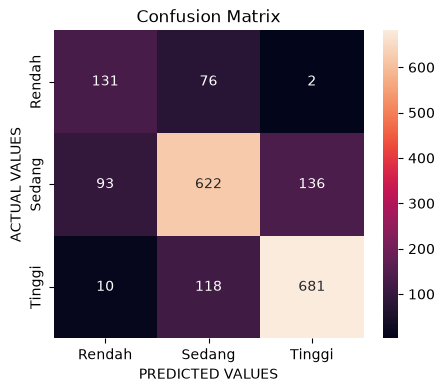

In [23]:
rfPred = grid_rf.predict(x_val)
cp = confusion_matrix(y_val, rfPred)
cp_df = pd.DataFrame(cp, index = ['Rendah','Sedang','Tinggi'], columns = ['Rendah','Sedang','Tinggi'])

plt.figure(figsize=(5,4))
sns.heatmap(cp_df, annot=True, fmt="d")
plt.title('Confusion Matrix')
plt.ylabel('ACTUAL VALUES')
plt.xlabel('PREDICTED VALUES')
plt.show()

In [24]:
print('Best Parameter:', grid_rf.best_params_)

Best Parameter: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 100, 'max_features': 'log2', 'max_leaf_nodes': 1000, 'min_samples_split': 2}


__Based on the Random Forest's Confusion Matrix__
- The model predicts the 'Tinggi' class most accurately, followed by 'Sedang'.
- 'Rendah' class is the most difficult class to classify, with many samples predicted as 'Sedang'.
- Most prediction errors occur between adjacent classes (Rendah - Sedang, Sedang - Tinggi), while direct confusion between Rendah and Tinggi is rare.

__Classification Performance__
- Overall accuracy: 76.7%.
- Performance on 'Rendah' is lower, likely due to class imbalance despite applying SMOTE during training.

__Best Random Forest Parameters__
- Criterion: Gini
- Max depth: 100
- Max features: log2
- Max leaf nodes: 1000
- Min samples split: 2
- Bootstrap: Enabled

### Bagging Classifier

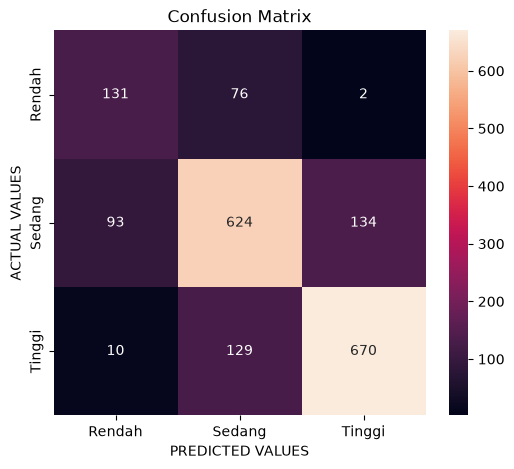

In [25]:
baggPred = grid_bagg.predict(x_val)
cp = confusion_matrix(y_val, baggPred)
cp_df = pd.DataFrame(cp, index = ['Rendah','Sedang','Tinggi'], columns = ['Rendah','Sedang','Tinggi'])

plt.figure(figsize=(6, 5))
sns.heatmap(cp_df, annot=True, fmt="d")
plt.title('Confusion Matrix')
plt.ylabel('ACTUAL VALUES')
plt.xlabel('PREDICTED VALUES')
plt.show()

In [26]:
grid_bagg.best_params_

{'bootstrap': False,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 100,
 'estimator__max_features': 'log2',
 'estimator__max_leaf_nodes': 1000,
 'estimator__min_samples_split': 3}

__Based on the Bagging Classifier's Confusion Matrix__
- The model predicts the 'Tinggi' class most accurately, followed by 'Sedang'.
- 'Rendah' class is the most difficult class to classify, with many samples predicted as 'Sedang'.
- Most prediction errors occur between adjacent classes (Rendah - Sedang, Sedang - Tinggi), while direct confusion between Rendah and Tinggi is rare.

__Classification Performance__
- Overall accuracy: 76.2%.
- Performance on 'Rendah' is lower, likely due to class imbalance despite applying SMOTE during training.

__Best Bagging Classifier Parameters__
- Criterion: Entropy
- Max depth: 100
- Max features: log2
- Max leaf nodes: 1000
- Min samples split: 3
- Bootstrap: Not enabled

## **INSIGHTS FROM TESTING SET**

### Predict using Testing Set

In [27]:
rfPred2 = grid_rf.predict(x_test)
print(rfPred2)

[2 2 1 ... 1 0 1]


### Combine Prediction with Unencoded Data

In [28]:
x2 = salarydf_copy.drop(['salary', 'Salary Level'], axis = 1)
y2 = salarydf_copy['Salary Level']

x_train, x_test, y_train, y_test = train_test_split(x2, y2, test_size = 0.20, shuffle = True, random_state = 42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, shuffle = True, random_state = 42)

salarydf2 = x_test.copy(deep = True)
salarydf2['Salary Level'] = rfPred2
salarydf2.head()

,job_title,location,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,Salary Level
4477,WORKFORCE MANAGEMENT (WFM),Jawa Tengah,Pegawai (non-manajemen & non-supervisor),1,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Pelayanan,Layanan Pelanggan","Asuransi kesehatan;Waktu regular, Senin - Juma...",17,201 - 500 pekerja,Manajemen/Konsulting HR,PT MITRACOMM EKASARANA bekerjasama dengan Perb...,2
871,Manager PPIC,DKI Jakarta,Manajer/Asisten Manajer,5,Tidak terspesifikasi,Penuh Waktu,"Teknik,Mekanikal","BPJS;uniform;Senin-Jumat, Sabtu(optional)",29,201 - 500 pekerja,Pameran/Manajemen acara/PIKP,Pendidikan min S1Max usia 45 tahunPengalaman d...,2
3463,BANCASSURANCE SPECIALIST - PADANG,Riau,Lulusan baru/Pengalaman kerja kurang dari 1 tahun,1,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Penjualan / Pemasaran,Penjualan - Jasa Keuangan",Tunjangan Pendidikan;Tip;Asuransi kesehatan;Ol...,7,2001 - 5000 pekerja,Asuransi,BANCASSURANCE SPECIALIST (BAS)Representative B...,1
2698,MARKETING,Jawa Timur,Pegawai (non-manajemen & non-supervisor),1,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Penjualan / Pemasaran,Telesales/Telemarketing",Tip;Asuransi kesehatan;Parkir;Formil (contoh: ...,27,51 - 200 pekerja,Industri Berat/Mesin/Peralatan,Kualifikasi:Pengalaman di bidang Marketing dan...,2
4534,HR Recruitment,DKI Jakarta,Pegawai (non-manajemen & non-supervisor),1,Sarjana (S1),Kontrak,"Sumber Daya Manusia/Personalia,Sumber Daya Man...",Asuransi Gigi;Tip;Asuransi kesehatan;Olahraga ...,28,2001 - 5000 pekerja,Telekomunikasi,KUALIFIKASIUsia max. 35 tahunPengalaman minima...,0


### Display Salary Levels based on Location, Career Level, and Job Function

In [29]:
salarydf2 = salarydf2[['location','career_level', 'job_function', 'Salary Level']]

for x in salarydf2.index :
    if (salarydf2['Salary Level'][x]) == 0 : 
      salarydf2['Salary Level'][x] = 'Rendah'
    elif (salarydf2['Salary Level'][x] == 1) :
      salarydf2['Salary Level'][x] = 'Sedang'
    elif (salarydf2['Salary Level'][x] == 2) :
      salarydf2['Salary Level'][x] = 'Tinggi'
      
salarydf2['Salary Level'] = salarydf2['Salary Level'].astype('object')
salarydf2.head()

,location,career_level,job_function,Salary Level
4477,Jawa Tengah,Pegawai (non-manajemen & non-supervisor),"Pelayanan,Layanan Pelanggan",Tinggi
871,DKI Jakarta,Manajer/Asisten Manajer,"Teknik,Mekanikal",Tinggi
3463,Riau,Lulusan baru/Pengalaman kerja kurang dari 1 tahun,"Penjualan / Pemasaran,Penjualan - Jasa Keuangan",Sedang
2698,Jawa Timur,Pegawai (non-manajemen & non-supervisor),"Penjualan / Pemasaran,Telesales/Telemarketing",Tinggi
4534,DKI Jakarta,Pegawai (non-manajemen & non-supervisor),"Sumber Daya Manusia/Personalia,Sumber Daya Man...",Rendah


### See Top 5 most popular jobs

In [30]:
salarydf2['job_function'].value_counts().head(10)

job_function
Penjualan / Pemasaran,Penjualan Ritel                      196
Komputer/Teknologi Informasi,IT-Perangkat Lunak            178
Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan           144
Penjualan / Pemasaran,Pemasaran/Pengembangan Bisnis        110
Sumber Daya Manusia/Personalia,Sumber Daya Manusia / HR     88
Sumber Daya Manusia/Personalia,Staf / Administrasi umum     73
Penjualan / Pemasaran,Digital Marketing                     69
Penjualan / Pemasaran,Penjualan - Korporasi                 61
Hotel/Restoran,Makanan/Minuman/Pelayanan Restoran           61
Seni/Media/Komunikasi,Seni / Desain Kreatif                 59
Name: count, dtype: int64

**Top 5 Most Popular Jobs based on the job function appearing most often on this dataset:**
1. `Penjualan / Pemasaran,Penjualan Ritel` (Sales / Marketing, Retail Sales)
2. `Komputer/Teknologi Informasi,IT-Perangkat Lunak` (Computers / Information Technology, IT - Software)
3. `Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan` (Accounting / Finance, General Accounting / Finance)
4. `Penjualan / Pemasaran,Pemasaran/Pengembangan Bisnis` (Sales / Marketing, Marketing / Business Development)
5. `Sumber Daya Manusia/Personalia,Sumber Daya Manusia / HR` (Human Resources / Personnel, Human Resources / HR)

### Insights from Top 5 Most Popular Jobs

#### 1. Penjualan / Pemasaran,Penjualan Ritel

In [31]:
top1 = salarydf2[(salarydf2['job_function'] == 'Penjualan / Pemasaran,Penjualan Ritel')]
top1.groupby(['job_function','career_level','location' ]).agg(pd.Series.mode)

Salary Level
job_function                          career_level                                      location                                   
Penjualan / Pemasaran,Penjualan Ritel CEO/GM/Direktur/Manajer Senior                    DKI Jakarta                          Tinggi
                                                                                        Sulawesi Utara                       Tinggi
                                      Lulusan baru/Pengalaman kerja kurang dari 1 tahun Banten                               Sedang
                                                                                        DKI Jakarta                          Rendah
                                                                                        Jawa Barat                 [Sedang, Tinggi]
                                                                                        Jawa Timur                           Sedang
                                                                                        Kalimantan Selatan                   Rendah
                                                                                        Sumatera Selatan                     Sedang
                                      Manajer/Asisten Manajer                           Bali                                 Tinggi
                                                                                        Banten                               Tinggi
                                                                                        DKI Jakarta                          Tinggi
                                                                                        Jawa Barat                           Tinggi
                                                                                        Jawa Tengah                          Tinggi
                                                                                        Kalimantan Barat                     Tinggi
                                                                                        NTT                                  Tinggi
                                                                                        Riau                                 Tinggi
                                                                                        Sumatera Barat                       Tinggi
                                                                                        Sumatera Selatan                     Tinggi
                                      Pegawai (non-manajemen & non-supervisor)          Bali                                 Sedang
                                                                                        Banten                               Sedang
                                                                                        Bengkulu                             Tinggi
                                                                                        DIY                                  Sedang
                                                                                        DKI Jakarta                          Sedang
                                                                                        Jambi                                Rendah
                                                                                        Jawa Barat                           Tinggi
                                                                                        Jawa Tengah                          Tinggi
                                                                                        Jawa Timur                           Tinggi
                                                                                        Kalimantan Barat                     Tinggi
                                                                                        Kalimantan Selatan                   Sedang
                           

__Explanations__:

This is the most popular job function. Most of people who work in this field tend to have average to high income, except for the fresh gaduates level in several provinces.

#### 2. Komputer/Teknologi Informasi,IT-Perangkat Lunak

In [32]:
top2 = salarydf2[(salarydf2['job_function'] == 'Komputer/Teknologi Informasi,IT-Perangkat Lunak')]
top2.groupby(['job_function','career_level','location']).agg(pd.Series.mode)

Salary Level
job_function                                    career_level                                      location                                   
Komputer/Teknologi Informasi,IT-Perangkat Lunak CEO/GM/Direktur/Manajer Senior                    DKI Jakarta                          Tinggi
                                                Lulusan baru/Pengalaman kerja kurang dari 1 tahun DIY                                  Tinggi
                                                                                                  DKI Jakarta                          Sedang
                                                                                                  Jawa Timur                           Tinggi
                                                Manajer/Asisten Manajer                           Bali                                 Tinggi
                                                                                                  DKI Jakarta                          Tinggi
                                                                                                  Jawa Tengah                          Tinggi
                                                Pegawai (non-manajemen & non-supervisor)          Bali                                 Tinggi
                                                                                                  Banten                     [Sedang, Tinggi]
                                                                                                  DIY                                  Tinggi
                                                                                                  DKI Jakarta                          Sedang
                                                                                                  Jawa Barat                           Tinggi
                                                                                                  Jawa Tengah                          Tinggi
                                                                                                  Jawa Timur                           Tinggi
                                                                                                  Kepulauan Bangka Belitung            Sedang
                                                                                                  Kepulauan Riau                       Tinggi
                                                                                                  NAD                                  Tinggi
                                                                                                  Sumatera Utara                       Tinggi
                                                Supervisor/Koordinator                            Bali                                 Tinggi
                                                                                                  Banten                               Tinggi
                                                                                                  DKI Jakarta                          Tinggi
                                                                                                  Jawa Barat                           Tinggi
                                                                                                  Jawa Timur                           Tinggi
                                                                                                  NAD                                  Tinggi
                                                                                                  Sumatera Utara                       Tinggi

__Explanation__:

This is also a popular and high demand job, with many provinces provide high level of salary based on their respective UMP. Even the fresh graduates also receive average to high income in this job field. Regardless of the career level, working in the IT field will most likely give you income 2x the minimum wage.

#### 3. Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan

In [33]:
top3 = salarydf2[(salarydf2['job_function'] == 'Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan')]
top3.groupby(['job_function','career_level','location']).agg(pd.Series.mode)

Salary Level
job_function                                     career_level                                      location                              
Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan CEO/GM/Direktur/Manajer Senior                    Jawa Barat                      Tinggi
                                                                                                   NAD                             Tinggi
                                                 Lulusan baru/Pengalaman kerja kurang dari 1 tahun DKI Jakarta                     Rendah
                                                 Manajer/Asisten Manajer                           Banten                          Tinggi
                                                                                                   DIY                             Tinggi
                                                                                                   DKI Jakarta                     Tinggi
                                                                                                   Jawa Barat                      Tinggi
                                                                                                   Jawa Tengah                     Tinggi
                                                                                                   Kalimantan Tengah               Tinggi
                                                                                                   Sulawesi Selatan                Tinggi
                                                 Pegawai (non-manajemen & non-supervisor)          Bali                            Tinggi
                                                                                                   Banten                          Tinggi
                                                                                                   DIY                             Sedang
                                                                                                   DKI Jakarta                     Sedang
                                                                                                   Jawa Barat                      Tinggi
                                                                                                   Jawa Timur                      Sedang
                                                                                                   Kalimantan Barat                Tinggi
                                                                                                   Kalimantan Utara                Sedang
                                                                                                   Sulawesi Tengah                 Tinggi
                                                                                                   Sumatera Utara                  Tinggi
                                                 Supervisor/Koordinator                            Banten                          Tinggi
                                                                                                   DIY                             Sedang
                                                                                                   DKI Jakarta                     Sedang
                                                                                                   Jawa Barat                      Tinggi
                                                                                                   Jawa Tengah                     Sedang
                                                                                                   Jawa Timur                      Tinggi
                                                                                                   Kepulauan Bangka Belitung       Tinggi
                                                                                                   NAD                     

__Explanation__:

Overall, a job field in accountant is a good career choice as most provinces rarely has people with salary under the minimum wage, regardless of the career level. Accounting companies still have a rapid growth in Indonesia, and it is also the third most in-demand job after IT and sales based on JobStreet.

#### 4. Penjualan / Pemasaran,Pemasaran/Pengembangan Bisnis

In [34]:
top4 = salarydf2[(salarydf2['job_function'] == 'Penjualan / Pemasaran,Pemasaran/Pengembangan Bisnis')]
top4.groupby(['job_function','career_level','location']).agg(pd.Series.mode)

Salary Level
job_function                                       career_level                                      location                            
Penjualan / Pemasaran,Pemasaran/Pengembangan Bi... CEO/GM/Direktur/Manajer Senior                    Banten                        Tinggi
                                                                                                     DKI Jakarta                   Tinggi
                                                                                                     Sumatera Utara                Tinggi
                                                   Lulusan baru/Pengalaman kerja kurang dari 1 tahun Banten                        Sedang
                                                                                                     DKI Jakarta                   Sedang
                                                                                                     Jawa Tengah                   Sedang
                                                                                                     Sumatera Utara                Rendah
                                                   Manajer/Asisten Manajer                           Bali                          Tinggi
                                                                                                     Banten              [Sedang, Tinggi]
                                                                                                     DKI Jakarta                   Tinggi
                                                                                                     Jawa Barat                    Tinggi
                                                                                                     Jawa Timur                    Tinggi
                                                                                                     Sumatera Utara                Tinggi
                                                   Pegawai (non-manajemen & non-supervisor)          Bali                          Sedang
                                                                                                     Banten                        Tinggi
                                                                                                     DKI Jakarta                   Sedang
                                                                                                     Jawa Barat                    Tinggi
                                                                                                     Jawa Tengah                   Tinggi
                                                                                                     Jawa Timur                    Sedang
                                                                                                     Kalimantan Timur              Sedang
                                                                                                     Papua                         Sedang
                                                                                                     Sumatera Barat                Sedang
                                                                                                     Sumatera Utara                Sedang
                                                   Supervisor/Koordinator                            Bali                          Tinggi
                                                                                                     DKI Jakarta                   Sedang
                                                                                                     Jawa Barat                    Tinggi
                                                                                                     Jawa Tengah                   Tinggi
                                                                                                     Jawa Timur            

__Explanation__:

Marketing/Business is also one of the most popular jobs, with salary level ranging from average to high.

#### 5. Sumber Daya Manusia/Personalia,Sumber Daya Manusia / HR

In [35]:
top5 = salarydf2[(salarydf2['job_function'] == 'Sumber Daya Manusia/Personalia,Sumber Daya Manusia / HR')]
top5.groupby(['job_function','career_level','location']).agg(pd.Series.mode)

Salary Level
job_function                                       career_level                                      location                            
Sumber Daya Manusia/Personalia,Sumber Daya Manu... CEO/GM/Direktur/Manajer Senior                    DKI Jakarta                   Tinggi
                                                                                                     NAD                           Tinggi
                                                   Lulusan baru/Pengalaman kerja kurang dari 1 tahun DKI Jakarta                   Rendah
                                                                                                     Jawa Timur                    Tinggi
                                                                                                     Sulawesi Tengah               Sedang
                                                   Manajer/Asisten Manajer                           Banten                        Sedang
                                                                                                     DKI Jakarta                   Tinggi
                                                                                                     Jawa Barat                    Tinggi
                                                                                                     Jawa Timur                    Tinggi
                                                   Pegawai (non-manajemen & non-supervisor)          Banten              [Sedang, Tinggi]
                                                                                                     DKI Jakarta                   Sedang
                                                                                                     Jawa Tengah                   Tinggi
                                                                                                     Jawa Timur                    Tinggi
                                                   Supervisor/Koordinator                            Banten                        Tinggi
                                                                                                     DKI Jakarta                   Sedang
                                                                                                     Jawa Barat                    Tinggi
                                                                                                     Jawa Tengah                   Tinggi
                                                                                                     Jawa Timur                    Tinggi
                                                                                                     Kalimantan Selatan            Tinggi

__Explanation__:

Human resource job in Indonesia mostly has a moderate to high salary level according to each location's minimum wage. However, employees who are fresh graduates can have income lower than minimum wage. Regardless, this is still a promising job in this country.

## **FINAL CONCLUSION**

### **Top 5 Most Popular Jobs in Indonesia**
1. Retail Sales
2. IT / Software Engineering
3. Accountant
4. Marketing / Business Development
5. Human Resource  

From the top 5 popular work fields, it is concluded that:
- These fields mostly provide Medium to High salary level in many provinces.
- The majority of available job locations are in Java (Especially DKI Jakarta).
- Most people in this data has a career level of an employee.

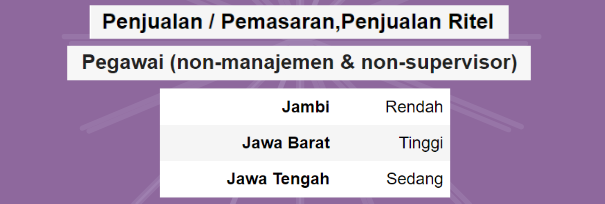

Salary levels are also strongly influenced by the field of work and the career position. Although the field of work and career position is the same, the location also affects the salary level you get. Working in DKI Jakarta, the capital of Indonesia, tends to give you a higher salary amount compared to other provinces.